# Laneless Highway Environment

Two-cell notebook: one cell for configuration/reference information, one cell that creates `env` from `src/environments/laneless/laneless_highway_env.py`.

## Config Information

In [6]:
from __future__ import annotations

import sys
from pathlib import Path
from pprint import pprint


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for root in [cwd, *cwd.parents, Path.home()]:
        candidates.extend(
            [
                root,
                root / "high-level-highway-rl",
                root / "code" / "high-level-highway-rl",
                root / "high-level-highway-rl",
                root / "high-level-highway-rl",
            ]
        )

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "Unstructured-Traffic_Environment").exists():
            return candidate

    raise RuntimeError(
        "Could not locate Unstructured-Traffic_Environment. "
        f"Kernel cwd is {cwd}. Start Jupyter from the high-level-highway-rl folder, "
        "or set PROJECT_ROOT manually to that folder."
    )


PROJECT_ROOT = find_project_root()
UNSTRUCTURED_ENV_ROOT = PROJECT_ROOT / "Unstructured-Traffic_Environment"
HIGHWAY_ENV_ROOT = UNSTRUCTURED_ENV_ROOT / "HighwayEnv"

for path in (UNSTRUCTURED_ENV_ROOT, HIGHWAY_ENV_ROOT):
    path_str = str(path)
    if path.exists() and path_str not in sys.path:
        sys.path.insert(0, path_str)

from Highway_Scenario.laneless.laneless_highway_env import (  # noqa: E402
    LanelessHighwayEnv,
    LanelessIDMVehicle,
)

ENV_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 8,
        "features": ["presence", "x", "y", "vx", "vy"],
        "features_range": {
            "x": [-100, 100],
            "y": [-8, 8],
            "vx": [-40, 40],
            "vy": [-10, 10],
        },
    },
    "action": {"type": "ContinuousAction"},
    "road_width": 12.0,
    "road_length": 10000.0,
    "lateral_bins_count": 10,
    "boundary_buffer": 0.5,
    "nominal_lane_width": 4.0,
    "vehicles_count": 20,
    "vehicles_density": 0.8,
    "ego_spacing": 2,
    "duration": 20,
    "speed_limit": 30,
    "target_speed_range": [0.8, 1.1],
    "policy_frequency": 5,
    "simulation_frequency": 15,
    "collision_reward": -1.0,
    "offroad_reward": -1.0,
    "high_speed_reward": 0.4,
    "reward_speed_range": [20, 30],
    "comfort_reward": -0.05,
    "normalize_reward": True,
    "offroad_terminal": True,
}

VEHICLE_MODELS = {
    "ego_vehicle": "Controlled by ContinuousAction through env.action_type.vehicle_class",
    "background_traffic": LanelessIDMVehicle.__name__,
    "background_longitudinal_model": "IDM acceleration",
    "background_lateral_model": "Sampled laneless lateral target with MOBIL-style safety/gain checks",
    "lateral_samples": LanelessIDMVehicle.LATERAL_SAMPLES,
    "lateral_decision_corridor_width_m": LanelessIDMVehicle.CORRIDOR_WIDTH,
    "lane_change_delay_s": LanelessIDMVehicle.LANE_CHANGE_DELAY,
}

ENVIRONMENT_PARAMETERS = {
    "environment_class": LanelessHighwayEnv.__name__,
    "source_file": UNSTRUCTURED_ENV_ROOT / "Highway_Scenario" / "laneless" / "laneless_highway_env.py",
    "road": {
        "type": "single wide hidden StraightLane corridor",
        "width_m": ENV_CONFIG["road_width"],
        "length_m": ENV_CONFIG["road_length"],
        "speed_limit_mps": ENV_CONFIG["speed_limit"],
        "lateral_spawn_bins": ENV_CONFIG["lateral_bins_count"],
    },
    "traffic": {
        "vehicles_count": ENV_CONFIG["vehicles_count"],
        "vehicles_density": ENV_CONFIG["vehicles_density"],
        "target_speed_range_fraction_of_limit": ENV_CONFIG["target_speed_range"],
        "ego_spawn_spacing": ENV_CONFIG["ego_spacing"],
    },
    "episode": {
        "duration_s": ENV_CONFIG["duration"],
        "policy_frequency_hz": ENV_CONFIG["policy_frequency"],
        "simulation_frequency_hz": ENV_CONFIG["simulation_frequency"],
    },
    "observation": ENV_CONFIG["observation"],
    "action": ENV_CONFIG["action"],
    "reward": {
        "collision_reward": ENV_CONFIG["collision_reward"],
        "offroad_reward": ENV_CONFIG["offroad_reward"],
        "high_speed_reward": ENV_CONFIG["high_speed_reward"],
        "comfort_reward": ENV_CONFIG["comfort_reward"],
        "reward_speed_range_mps": ENV_CONFIG["reward_speed_range"],
        "normalize_reward": ENV_CONFIG["normalize_reward"],
    },
    "termination": {
        "collision_terminal": True,
        "offroad_terminal": ENV_CONFIG["offroad_terminal"],
    },
}

print("Vehicle models")
pprint(VEHICLE_MODELS)
print("\nEnvironment parameters")
pprint(ENVIRONMENT_PARAMETERS)

Vehicle models
{'background_lateral_model': 'Sampled laneless lateral target with MOBIL-style '
                             'safety/gain checks',
 'background_longitudinal_model': 'IDM acceleration',
 'background_traffic': 'LanelessIDMVehicle',
 'ego_vehicle': 'Controlled by ContinuousAction through '
                'env.action_type.vehicle_class',
 'lane_change_delay_s': 1.0,
 'lateral_decision_corridor_width_m': 2.8,
 'lateral_samples': 21}

Environment parameters
{'action': {'type': 'ContinuousAction'},
 'environment_class': 'LanelessHighwayEnv',
 'episode': {'duration_s': 20,
             'policy_frequency_hz': 5,
             'simulation_frequency_hz': 15},
 'observation': {'features': ['presence', 'x', 'y', 'vx', 'vy'],
                 'features_range': {'vx': [-40, 40],
                                    'vy': [-10, 10],
                                    'x': [-100, 100],
                                    'y': [-8, 8]},
                 'type': 'Kinematics',
            

## Env

env: <LanelessHighwayEnv instance>
Observation shape: (8, 5)
Next observation shape: (8, 5)
Action space: Box(-1.0, 1.0, (2,), float32)
Reward after one zero-action step: 0.9166666666666667
Terminated: False
Truncated: False
Vehicles on road: 21
Ego vehicle class: Vehicle
Ego position: [209.83078455   0.        ]
Ego speed: 25.0


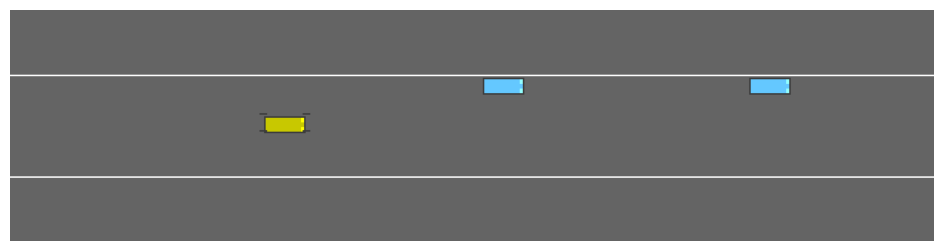

In [7]:
import matplotlib.pyplot as plt
import numpy as np

env = LanelessHighwayEnv(config=ENV_CONFIG, render_mode="rgb_array")
obs, info = env.reset(seed=0)

zero_action = np.zeros(env.action_space.shape, dtype=env.action_space.dtype)
next_obs, reward, terminated, truncated, step_info = env.step(zero_action)
frame = env.render()

print("env:", env)
print("Observation shape:", obs.shape)
print("Next observation shape:", next_obs.shape)
print("Action space:", env.action_space)
print("Reward after one zero-action step:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Vehicles on road:", len(env.road.vehicles))
print("Ego vehicle class:", type(env.vehicle).__name__)
print("Ego position:", env.vehicle.position)
print("Ego speed:", env.vehicle.speed)

plt.figure(figsize=(12, 3))
plt.imshow(frame)
plt.axis("off");

## Continuous Driver Aggressiveness

In [ ]:
from pprint import pprint

import numpy as np


DRIVER_PROFILE_KEYS = {
    "target_speed": "target_speed",
    "acc_max": "ACC_MAX",
    "comfort_acc_max": "COMFORT_ACC_MAX",
    "comfort_acc_min": "COMFORT_ACC_MIN",
    "delta": "DELTA",
    "time_wanted": "TIME_WANTED",
    "distance_wanted": "DISTANCE_WANTED",
    "politeness": "POLITENESS",
    "lane_change_min_acc_gain": "LANE_CHANGE_MIN_ACC_GAIN",
    "lane_change_max_braking_imposed": "LANE_CHANGE_MAX_BRAKING_IMPOSED",
    "lane_change_delay": "LANE_CHANGE_DELAY",
    "lateral_safe_margin": "LATERAL_SAFE_MARGIN",
    "lateral_clearance": "LATERAL_CLEARANCE",
    "max_lateral_decision_distance": "MAX_LATERAL_DECISION_DISTANCE",
}

CONSERVATIVE_DRIVER_PROFILE = {
    "target_speed": 20.0,
    "acc_max": 4.0,
    "comfort_acc_max": 2.0,
    "comfort_acc_min": -4.0,
    "delta": 4.5,
    "time_wanted": 2.4,
    "distance_wanted": 14.0,
    "politeness": 0.8,
    "lane_change_min_acc_gain": 0.8,
    "lane_change_max_braking_imposed": 1.0,
    "lane_change_delay": 1.5,
    "lateral_safe_margin": 0.8,
    "lateral_clearance": 0.8,
    "max_lateral_decision_distance": 1.5,
}

AGGRESSIVE_DRIVER_PROFILE = {
    "target_speed": 30.0,
    "acc_max": 7.0,
    "comfort_acc_max": 5.5,
    "comfort_acc_min": -6.5,
    "delta": 3.5,
    "time_wanted": 0.6,
    "distance_wanted": 6.0,
    "politeness": 0.0,
    "lane_change_min_acc_gain": 0.05,
    "lane_change_max_braking_imposed": 3.5,
    "lane_change_delay": 0.5,
    "lateral_safe_margin": 0.2,
    "lateral_clearance": 0.2,
    "max_lateral_decision_distance": 4.0,
}


def interpolate_driver_profile(score: float) -> dict[str, float]:
    t = float(np.clip(score, 0.0, 100.0)) / 100.0
    return {
        key: (1.0 - t) * CONSERVATIVE_DRIVER_PROFILE[key] + t * AGGRESSIVE_DRIVER_PROFILE[key]
        for key in CONSERVATIVE_DRIVER_PROFILE
    }


def apply_laneless_driver_aggressiveness(vehicle: LanelessIDMVehicle, score: float) -> None:
    profile = interpolate_driver_profile(score)
    for profile_key, vehicle_attribute in DRIVER_PROFILE_KEYS.items():
        setattr(vehicle, vehicle_attribute, float(profile[profile_key]))
    vehicle.driver_aggressiveness_score = float(np.clip(score, 0.0, 100.0))
    vehicle.driver_profile = profile


example_scores = [0, 25, 50, 75, 100]

print("Aggressiveness scale: 0 = most conservative, 100 = most aggressive")
print("Available example scores:", example_scores)
print("Example conservative profile")
pprint(interpolate_driver_profile(0))
print("\nExample balanced profile")
pprint(interpolate_driver_profile(50))
print("\nExample aggressive profile")
pprint(interpolate_driver_profile(100))

## RL Formulation: DQN And Continuous Control

In [9]:
from functools import partial

from gymnasium import spaces
from highway_env.envs.common.action import ActionType
from highway_env.envs.common.observation import observation_factory
from highway_env.vehicle.graphics import VehicleGraphics
from highway_env.vehicle.kinematics import Vehicle


EGO_RENDER_COLOR = (255, 80, 30)
_ORIGINAL_VEHICLE_GET_COLOR = getattr(VehicleGraphics, "_original_get_color", VehicleGraphics.get_color)
VehicleGraphics._original_get_color = _ORIGINAL_VEHICLE_GET_COLOR


def ego_aware_vehicle_color(cls, vehicle, transparent=False):
    if getattr(vehicle, "is_ego_vehicle", False):
        color = getattr(vehicle, "color", EGO_RENDER_COLOR)
        return (*color, 30) if transparent else color
    return cls._original_get_color(vehicle, transparent)


VehicleGraphics.get_color = classmethod(ego_aware_vehicle_color)


class LanelessTargetVehicle(LanelessIDMVehicle):
    """Ego vehicle controlled by target speed and continuous lateral target."""

    def __init__(self, *args, road_width=None, target_boundary_margin=None, **kwargs):
        super().__init__(*args, enable_lane_change=False, road_width=road_width, **kwargs)
        self.color = EGO_RENDER_COLOR
        self.is_ego_vehicle = True
        self.target_boundary_margin = float(target_boundary_margin or self.BOUNDARY_MARGIN)

    def lateral_bounds(self) -> tuple[float, float]:
        margin = max(self.BOUNDARY_MARGIN, self.target_boundary_margin)
        return -self.road_width / 2 + margin, self.road_width / 2 - margin

    def act(self, action=None):
        if self.crashed:
            return

        if action:
            if "target_speed_delta" in action:
                self.target_speed += float(action["target_speed_delta"])
            if "target_speed" in action:
                self.target_speed = float(action["target_speed"])
            if "target_y_delta" in action:
                self.target_y += float(action["target_y_delta"])
            if "target_y" in action:
                self.target_y = float(action["target_y"])

        low_y, high_y = self.lateral_bounds()
        speed_limit = self.lane.speed_limit or 40.0
        self.target_y = float(np.clip(self.target_y, low_y, high_y))
        self.target_speed = float(np.clip(self.target_speed, 0.0, speed_limit))

        low_level_action = {
            "acceleration": self.speed_control(self.target_speed),
            "steering": self.steering_to_lateral_target(self.target_y),
        }
        low_level_action["acceleration"] = float(
            np.clip(low_level_action["acceleration"], -self.ACC_MAX, self.ACC_MAX)
        )
        low_level_action["steering"] = float(
            np.clip(low_level_action["steering"], -self.MAX_STEERING_ANGLE, self.MAX_STEERING_ANGLE)
        )
        Vehicle.act(self, low_level_action)


class LanelessDiscreteLocalAction(ActionType):
    """DQN action: 3 longitudinal choices x local lateral shifts from -3 to +3 bins."""

    LONGITUDINAL_COMMANDS = {-1: "SLOWER", 0: "IDLE", 1: "FASTER"}

    def __init__(self, env, speed_delta: float = 3.0, max_lateral_bins: int = 3, **kwargs):
        super().__init__(env)
        self.speed_delta = float(speed_delta)
        self.max_lateral_bins = int(max_lateral_bins)
        self.bin_width = float(env.config["road_width"]) / float(env.config["lateral_bins_count"])
        self.actions = [
            (longitudinal, lateral_bins)
            for longitudinal in (-1, 0, 1)
            for lateral_bins in range(-self.max_lateral_bins, self.max_lateral_bins + 1)
        ]
        self.action_labels = {
            index: f"{self.LONGITUDINAL_COMMANDS[longitudinal]} / lateral {lateral_bins:+d} bins"
            for index, (longitudinal, lateral_bins) in enumerate(self.actions)
        }

    def space(self):
        return spaces.Discrete(len(self.actions))

    @property
    def vehicle_class(self):
        return partial(
            LanelessTargetVehicle,
            road_width=self.env.config["road_width"],
            target_boundary_margin=self.env.config.get("target_boundary_margin", 1.8),
        )

    def act(self, action: int) -> None:
        longitudinal, lateral_bins = self.actions[int(action)]
        lateral_command = float(lateral_bins / max(1, self.max_lateral_bins))
        self.controlled_vehicle.last_lateral_command = lateral_command
        self.controlled_vehicle.act(
            {
                "target_speed_delta": longitudinal * self.speed_delta,
                "target_y_delta": lateral_bins * self.bin_width,
            }
        )

    def get_available_actions(self):
        vehicle = self.controlled_vehicle
        low_y, high_y = vehicle.lateral_bounds()
        available = []
        for index, (_, lateral_bins) in enumerate(self.actions):
            candidate_y = vehicle.target_y + lateral_bins * self.bin_width
            if low_y <= candidate_y <= high_y:
                available.append(index)
        return available


class LanelessContinuousLocalAction(ActionType):
    """Continuous action: [speed_delta, lateral_delta], both normalized to [-1, 1]."""

    def __init__(self, env, speed_delta: float = 3.0, max_lateral_bins: int = 3, **kwargs):
        super().__init__(env)
        self.speed_delta = float(speed_delta)
        self.max_lateral_bins = int(max_lateral_bins)
        self.bin_width = float(env.config["road_width"]) / float(env.config["lateral_bins_count"])
        self.max_lateral_delta = self.max_lateral_bins * self.bin_width

    def space(self):
        return spaces.Box(-1.0, 1.0, shape=(2,), dtype=np.float32)

    @property
    def vehicle_class(self):
        return partial(
            LanelessTargetVehicle,
            road_width=self.env.config["road_width"],
            target_boundary_margin=self.env.config.get("target_boundary_margin", 1.8),
        )

    def act(self, action: np.ndarray) -> None:
        action = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        self.controlled_vehicle.last_lateral_command = float(action[1])
        self.controlled_vehicle.act(
            {
                "target_speed_delta": float(action[0]) * self.speed_delta,
                "target_y_delta": float(action[1]) * self.max_lateral_delta,
            }
        )


class LanelessRLRewardMixin:
    @classmethod
    def default_config(cls) -> dict:
        config = super().default_config()
        config.update(
            {
                "ttc_penalty": -0.6,
                "ttc_threshold": 4.0,
                "ttc_lateral_margin": 0.5,
                "traffic_lag_penalty": -0.3,
                "traffic_lag_speed_tolerance": 1.0,
                "traffic_lag_max_speed_error": 10.0,
                "local_traffic_radius": 120.0,
                "target_boundary_margin": 1.8,
                "boundary_penalty": -0.35,
                "middle_position_reward": 0.12,
                "target_lateral_penalty": -0.04,
                "lateral_action_penalty": -0.02,
                "overtake_event_reward": 0.45,
                "overtake_setup_reward": 0.25,
                "speed_advantage_reward": 0.15,
                "rear_pressure_reward": 0.0,
                "rear_pressure_radius": 80.0,
                "rear_pressure_ttc": 5.0,
                "rear_pressure_speed_tolerance": 1.0,
                "rear_pressure_max_speed_error": 10.0,
                "overtake_front_radius": 80.0,
                "overtake_lateral_clearance": 2.5,
                "overtake_speed_margin": 0.5,
                "normalize_shaping_reward": True,
                "spatial_shaping_reward_weight": 0.25,
                "safety_flow_shaping_reward_weight": 0.35,
                "overtaking_shaping_reward_weight": 0.35,
            }
        )
        return config

    def reset(self, *args, **kwargs):
        self._reward_seen_ahead_ids = set()
        self._reward_overtaken_ids = set()
        return super().reset(*args, **kwargs)

    def _front_ttc(self) -> float:
        ego = self.vehicle
        ego_s, ego_y = ego.lane.local_coordinates(ego.position)
        ego_vx = ego.speed * np.cos(ego.heading)
        min_ttc = np.inf

        for other in self.road.vehicles:
            if other is ego:
                continue
            other_s, other_y = ego.lane.local_coordinates(other.position)
            dx = other_s - ego_s
            if dx <= 0:
                continue
            lateral_overlap = abs(other_y - ego_y) <= (
                ego.WIDTH / 2 + other.WIDTH / 2 + self.config["ttc_lateral_margin"]
            )
            if not lateral_overlap:
                continue
            other_vx = other.speed * np.cos(other.heading)
            closing_speed = ego_vx - other_vx
            if closing_speed > 1e-6:
                min_ttc = min(min_ttc, dx / closing_speed)

        return float(min_ttc)

    def _ttc_safety_reward(self) -> float:
        min_ttc = self._front_ttc()
        if not np.isfinite(min_ttc):
            return 1.0
        return float(np.clip(min_ttc / self.config["ttc_threshold"], 0.0, 1.0))

    def _traffic_flow_reward(self) -> float:
        ego = self.vehicle
        ego_s, _ = ego.lane.local_coordinates(ego.position)
        nearby_speeds = []
        for other in self.road.vehicles:
            if other is ego:
                continue
            other_s, _ = ego.lane.local_coordinates(other.position)
            if abs(other_s - ego_s) <= self.config["local_traffic_radius"]:
                nearby_speeds.append(float(other.speed))

        if not nearby_speeds:
            return 1.0
        local_mean_speed = float(np.mean(nearby_speeds))
        lag = max(0.0, local_mean_speed - ego.speed - self.config["traffic_lag_speed_tolerance"])
        normalized_lag = np.clip(lag / self.config["traffic_lag_max_speed_error"], 0.0, 1.0)
        return float(1.0 - normalized_lag)

    def _local_traffic_speed(self) -> float:
        ego = self.vehicle
        ego_s, _ = ego.lane.local_coordinates(ego.position)
        nearby_speeds = []
        for other in self.road.vehicles:
            if other is ego:
                continue
            other_s, _ = ego.lane.local_coordinates(other.position)
            if abs(other_s - ego_s) <= self.config["local_traffic_radius"]:
                nearby_speeds.append(float(other.speed))
        return float(np.mean(nearby_speeds)) if nearby_speeds else float(ego.speed)

    def _speed_advantage_reward(self) -> float:
        speed_advantage = self.vehicle.speed - self._local_traffic_speed()
        return float(np.clip((speed_advantage + 1.0) / self.config["traffic_lag_max_speed_error"], 0.0, 1.0))

    def _rear_pressure_reward(self) -> float:
        ego = self.vehicle
        ego_s, ego_y = ego.lane.local_coordinates(ego.position)
        strongest_pressure = 0.0
        for other in self.road.vehicles:
            if other is ego:
                continue
            other_s, other_y = ego.lane.local_coordinates(other.position)
            dx = float(ego_s - other_s)
            if dx <= 0.0 or dx > self.config["rear_pressure_radius"]:
                continue
            lateral_overlap = abs(float(other_y - ego_y)) <= (
                ego.WIDTH / 2 + other.WIDTH / 2 + self.config["ttc_lateral_margin"]
            )
            if not lateral_overlap:
                continue
            closing_speed = other.speed - ego.speed
            if closing_speed <= 1e-6:
                continue
            rear_ttc = dx / closing_speed
            pressure = np.clip((self.config["rear_pressure_ttc"] - rear_ttc) / self.config["rear_pressure_ttc"], 0.0, 1.0)
            speed_deficit = max(0.0, closing_speed - self.config["rear_pressure_speed_tolerance"])
            speed_match = 1.0 - np.clip(speed_deficit / self.config["rear_pressure_max_speed_error"], 0.0, 1.0)
            strongest_pressure = max(strongest_pressure, float(pressure * speed_match))
        return float(strongest_pressure)

    def _overtake_event_reward(self) -> float:
        if not hasattr(self, "_reward_seen_ahead_ids"):
            self._reward_seen_ahead_ids = set()
            self._reward_overtaken_ids = set()

        ego = self.vehicle
        ego_s, _ = ego.lane.local_coordinates(ego.position)
        completed_overtakes = 0
        for other in self.road.vehicles:
            if other is ego:
                continue
            other_id = id(other)
            other_s, _ = ego.lane.local_coordinates(other.position)
            dx = float(other_s - ego_s)
            if dx > 0.0:
                self._reward_seen_ahead_ids.add(other_id)
            elif other_id in self._reward_seen_ahead_ids and other_id not in self._reward_overtaken_ids:
                self._reward_overtaken_ids.add(other_id)
                completed_overtakes += 1
        return float(np.clip(completed_overtakes, 0, 1))

    def _overtake_setup_reward(self) -> float:
        ego = self.vehicle
        ego_s, ego_y = ego.lane.local_coordinates(ego.position)
        best_setup = 0.0
        for other in self.road.vehicles:
            if other is ego:
                continue
            other_s, other_y = ego.lane.local_coordinates(other.position)
            dx = float(other_s - ego_s)
            if dx <= 0.0 or dx > self.config["overtake_front_radius"]:
                continue
            speed_advantage = np.clip(
                (ego.speed - other.speed - self.config["overtake_speed_margin"])
                / self.config["traffic_lag_max_speed_error"],
                0.0,
                1.0,
            )
            lateral_clearance = np.clip(
                abs(float(other_y - ego_y)) / self.config["overtake_lateral_clearance"],
                0.0,
                1.0,
            )
            distance_gate = 1.0 - np.clip(dx / self.config["overtake_front_radius"], 0.0, 1.0)
            best_setup = max(best_setup, float(speed_advantage * lateral_clearance * distance_gate))
        return float(best_setup)

    def _normalized_lateral_distance(self) -> float:
        ego = self.vehicle
        _, ego_y = ego.lane.local_coordinates(ego.position)
        half_width = 0.5 * self.config["road_width"]
        usable_half_width = max(1e-6, half_width - self.config["target_boundary_margin"])
        return float(np.clip(abs(ego_y) / usable_half_width, 0.0, 1.0))

    def _boundary_margin_reward(self) -> float:
        normalized_distance = self._normalized_lateral_distance()
        return float(1.0 - normalized_distance**2)

    def _middle_position_reward(self) -> float:
        normalized_distance = self._normalized_lateral_distance()
        return float(1.0 - normalized_distance)

    def _target_lateral_penalty(self) -> float:
        ego = self.vehicle
        target_y = float(getattr(ego, "target_y", 0.0))
        half_width = 0.5 * self.config["road_width"]
        usable_half_width = max(1e-6, half_width - self.config["target_boundary_margin"])
        return float(np.clip(abs(target_y) / usable_half_width, 0.0, 1.0))

    def _lateral_action_penalty(self) -> float:
        return float(np.clip(abs(getattr(self.vehicle, "last_lateral_command", 0.0)), 0.0, 1.0))

    def _spatial_shaping_components(self, rewards: dict[str, float]) -> dict[str, float]:
        return {
            "boundary_penalty": self.config["boundary_penalty"] * (1.0 - rewards["boundary_margin_reward"]),
            "middle_position_reward": self.config["middle_position_reward"] * rewards["middle_position_reward"],
            "target_lateral_penalty": self.config["target_lateral_penalty"] * rewards["target_lateral_penalty"],
            "lateral_action_penalty": self.config["lateral_action_penalty"] * rewards["lateral_action_penalty"],
        }

    def _safety_flow_shaping_components(self, rewards: dict[str, float]) -> dict[str, float]:
        return {
            "ttc_penalty": self.config["ttc_penalty"] * (1.0 - rewards["ttc_safety_reward"]),
            "traffic_lag_penalty": self.config["traffic_lag_penalty"] * (1.0 - rewards["traffic_flow_reward"]),
        }

    def _overtaking_shaping_components(self, rewards: dict[str, float]) -> dict[str, float]:
        safe_gate = rewards["ttc_safety_reward"] * rewards["boundary_margin_reward"]
        return {
            "overtake_event_reward": self.config["overtake_event_reward"] * rewards["overtake_event_reward"],
            "overtake_setup_reward": self.config["overtake_setup_reward"] * rewards["overtake_setup_reward"] * safe_gate,
            "speed_advantage_reward": self.config["speed_advantage_reward"] * rewards["speed_advantage_reward"] * safe_gate,
            "rear_pressure_reward": self.config["rear_pressure_reward"] * rewards["rear_pressure_reward"] * safe_gate,
        }

    def _normalize_component_sum(self, components: dict[str, float]) -> float:
        raw_shaping = float(sum(components.values()))
        if not self.config.get("normalize_shaping_reward", True):
            return raw_shaping

        positive_scale = max(
            1e-6,
            sum(max(0.0, float(self.config[key])) for key in components),
        )
        negative_scale = max(
            1e-6,
            sum(abs(min(0.0, float(self.config[key]))) for key in components),
        )
        normalized = raw_shaping / (positive_scale if raw_shaping >= 0.0 else negative_scale)
        return float(np.clip(normalized, -1.0, 1.0))

    def _shaping_components(self, rewards: dict[str, float]) -> dict[str, float]:
        return {
            **self._spatial_shaping_components(rewards),
            **self._safety_flow_shaping_components(rewards),
            **self._overtaking_shaping_components(rewards),
        }

    def _normalized_shaping_reward(self, rewards: dict[str, float]) -> float:
        spatial = self._normalize_component_sum(self._spatial_shaping_components(rewards))
        safety_flow = self._normalize_component_sum(self._safety_flow_shaping_components(rewards))
        overtaking = self._normalize_component_sum(self._overtaking_shaping_components(rewards))
        return float(
            self.config["spatial_shaping_reward_weight"] * spatial
            + self.config["safety_flow_shaping_reward_weight"] * safety_flow
            + self.config["overtaking_shaping_reward_weight"] * overtaking
        )

    def _rewards(self, action) -> dict[str, float]:
        rewards = super()._rewards(action)
        rewards["ttc_safety_reward"] = self._ttc_safety_reward()
        rewards["traffic_flow_reward"] = self._traffic_flow_reward()
        rewards["boundary_margin_reward"] = self._boundary_margin_reward()
        rewards["middle_position_reward"] = self._middle_position_reward()
        rewards["target_lateral_penalty"] = self._target_lateral_penalty()
        rewards["lateral_action_penalty"] = self._lateral_action_penalty()
        rewards["overtake_event_reward"] = self._overtake_event_reward()
        rewards["overtake_setup_reward"] = self._overtake_setup_reward()
        rewards["speed_advantage_reward"] = self._speed_advantage_reward()
        rewards["rear_pressure_reward"] = self._rear_pressure_reward()
        rewards["normalized_shaping_reward"] = self._normalized_shaping_reward(rewards)
        return rewards

    def _reward(self, action) -> float:
        reward = super()._reward(action)
        rewards = self._rewards(action)
        reward += rewards["normalized_shaping_reward"]
        return float(reward)


class LanelessDQNEnv(LanelessRLRewardMixin, LanelessHighwayEnv):
    def define_spaces(self) -> None:
        self.observation_type = observation_factory(self, self.config["observation"])
        self.action_type = LanelessDiscreteLocalAction(
            self,
            speed_delta=self.config.get("speed_delta", 3.0),
            max_lateral_bins=self.config.get("max_lateral_bins", 3),
        )
        self.observation_space = self.observation_type.space()
        self.action_space = self.action_type.space()


class LanelessContinuousRLTargetEnv(LanelessRLRewardMixin, LanelessHighwayEnv):
    def define_spaces(self) -> None:
        self.observation_type = observation_factory(self, self.config["observation"])
        self.action_type = LanelessContinuousLocalAction(
            self,
            speed_delta=self.config.get("speed_delta", 3.0),
            max_lateral_bins=self.config.get("max_lateral_bins", 3),
        )
        self.observation_space = self.observation_type.space()
        self.action_space = self.action_type.space()


LANELESS_RL_CONFIG = {
    **ENV_CONFIG,
    "speed_delta": 3.0,
    "max_lateral_bins": 3,
    "ttc_penalty": -0.6,
    "traffic_lag_penalty": -0.3,
    "traffic_lag_speed_tolerance": 1.0,
    "target_boundary_margin": 1.8,
    "boundary_penalty": -0.35,
    "middle_position_reward": 0.12,
    "target_lateral_penalty": -0.04,
    "lateral_action_penalty": -0.02,
    "overtake_event_reward": 0.45,
    "overtake_setup_reward": 0.25,
    "speed_advantage_reward": 0.15,
    "overtake_front_radius": 80.0,
    "overtake_lateral_clearance": 2.5,
    "overtake_speed_margin": 0.5,
    "normalize_shaping_reward": True,
    "spatial_shaping_reward_weight": 0.25,
    "safety_flow_shaping_reward_weight": 0.35,
    "overtaking_shaping_reward_weight": 0.35,
}
SAC_LANELESS_RL_CONFIG = {
    **LANELESS_RL_CONFIG,
    "duration": 3 * LANELESS_RL_CONFIG["duration"],
    "max_lateral_bins": 3,
}

print("DQN action count:", 3 * (2 * LANELESS_RL_CONFIG["max_lateral_bins"] + 1))
print("SAC episode duration:", SAC_LANELESS_RL_CONFIG["duration"])
print("SAC lateral action range (m):", SAC_LANELESS_RL_CONFIG["max_lateral_bins"] * (SAC_LANELESS_RL_CONFIG["road_width"] / SAC_LANELESS_RL_CONFIG["lateral_bins_count"]))
print("Recommended continuous algorithm: SAC first, PPO as a stability baseline, TD3 only after SAC/PPO.")

DQN action count: 21
SAC episode duration: 60
SAC lateral action range (m): 3.5999999999999996
Recommended continuous algorithm: SAC first, PPO as a stability baseline, TD3 only after SAC/PPO.


## RL Environment Smoke Test

In [ ]:
dqn_env = LanelessDQNEnv(config=LANELESS_RL_CONFIG, render_mode="rgb_array")
dqn_obs, dqn_info = dqn_env.reset(seed=21)
dqn_action = dqn_env.action_space.sample()
dqn_next_obs, dqn_reward, dqn_terminated, dqn_truncated, dqn_step_info = dqn_env.step(dqn_action)

continuous_env = LanelessContinuousRLTargetEnv(config=LANELESS_RL_CONFIG, render_mode="rgb_array")
continuous_obs, continuous_info = continuous_env.reset(seed=21)
continuous_action = continuous_env.action_space.sample()
continuous_next_obs, continuous_reward, continuous_terminated, continuous_truncated, continuous_step_info = continuous_env.step(continuous_action)

print("DQN env")
print("  observation space:", dqn_env.observation_space)
print("  action space:", dqn_env.action_space)
print("  sampled action:", dqn_action, dqn_env.action_type.action_labels[int(dqn_action)])
print("  reward:", dqn_reward)
print("  reward terms:")
pprint(dqn_step_info["rewards"])

print("\nContinuous env")
print("  observation space:", continuous_env.observation_space)
print("  action space:", continuous_env.action_space)
print("  sampled action [speed_delta, lateral_delta]:", continuous_action)
print("  reward:", continuous_reward)
print("  reward terms:")
pprint(continuous_step_info["rewards"])

dqn_env.close()
continuous_env.close()

## Training Setup

In [10]:
import json
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display
from stable_baselines3 import DQN, SAC
from stable_baselines3.common.callbacks import BaseCallback, CallbackList, EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

TRAINING_TIMESTEPS = 300_000
LANELESS_TRAINING_RUN_SUFFIX = "300k_timesteps"
LANELESS_SAC_TRAINING_RUN_SUFFIX = "300k_timesteps_overtake_v2"
LANELESS_DQN_RUN_NAME = f"laneless_dqn_{LANELESS_TRAINING_RUN_SUFFIX}"
LANELESS_SAC_RUN_NAME = f"laneless_sac_{LANELESS_SAC_TRAINING_RUN_SUFFIX}"
SAVED_MODEL_EVAL_EPISODES = 1_000
TRAINING_EVAL_EPISODES = 10
EVAL_EVERY_TIMESTEPS = 10_000
N_ENVS = 4
DQN_POLICY_KWARGS = {"net_arch": [256, 256]}
SAC_POLICY_KWARGS = {"net_arch": [256, 256]}
SEED = 42
DEFAULT_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "laneless_highway_env"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


class TimestepProgressCallback(BaseCallback):
    def __init__(self, total_timesteps: int, every_n_steps: int = 2_000):
        super().__init__(verbose=0)
        self.total_timesteps = max(1, int(total_timesteps))
        self.every_n_steps = max(1, int(every_n_steps))
        self.next_print = self.every_n_steps

    def _on_step(self) -> bool:
        if self.num_timesteps >= self.next_print:
            progress = min(100.0, 100.0 * self.num_timesteps / self.total_timesteps)
            print(f"[train] {self.num_timesteps}/{self.total_timesteps} timesteps ({progress:.1f}%)", flush=True)
            while self.next_print <= self.num_timesteps:
                self.next_print += self.every_n_steps
        return True


def make_monitored_env(env_cls, config: dict, seed: int, monitor_dir: Path, rank: int = 0):
    def _init():
        env = env_cls(config=config, render_mode=None)
        env.reset(seed=seed + rank)
        return Monitor(env, filename=str(monitor_dir / f"env_{rank}.monitor.csv"))

    return _init


def make_vec_laneless_env(env_cls, config: dict, seed: int, monitor_dir: Path, n_envs: int = N_ENVS):
    monitor_dir.mkdir(parents=True, exist_ok=True)
    return DummyVecEnv([
        make_monitored_env(env_cls, config, seed=seed, monitor_dir=monitor_dir, rank=rank)
        for rank in range(int(n_envs))
    ])


def make_eval_env(env_cls, config: dict, seed: int):
    env = env_cls(config=config, render_mode=None)
    env.reset(seed=seed)
    return Monitor(env)


def make_training_callbacks(eval_env, run_dir: Path, n_envs: int):
    callbacks = [
        TimestepProgressCallback(TRAINING_TIMESTEPS, every_n_steps=EVAL_EVERY_TIMESTEPS),
        EvalCallback(
            eval_env,
            best_model_save_path=str(run_dir / "best_model"),
            log_path=str(run_dir / "eval_tracker"),
            eval_freq=max(EVAL_EVERY_TIMESTEPS // max(1, int(n_envs)), 1),
            n_eval_episodes=TRAINING_EVAL_EPISODES,
            deterministic=True,
            render=False,
        ),
    ]
    return CallbackList(callbacks)


def compute_laneless_ttc(env, ttc_cap: float = 10.0) -> float:
    ttc = env.unwrapped._front_ttc() if hasattr(env.unwrapped, "_front_ttc") else np.inf
    if not np.isfinite(ttc):
        return float(ttc_cap)
    return float(np.clip(ttc, 0.0, ttc_cap))


def update_overtake_tracker(env, seen_ahead_ids: set, overtaken_ids: set) -> None:
    ego = env.unwrapped.vehicle
    ego_x = float(ego.position[0])
    for other in env.unwrapped.road.vehicles:
        if other is ego:
            continue
        other_id = id(other)
        dx = float(other.position[0] - ego_x)
        if dx > 0.0:
            seen_ahead_ids.add(other_id)
        elif other_id in seen_ahead_ids:
            overtaken_ids.add(other_id)


def evaluate_laneless_model(model, env_cls, config: dict, episodes: int, seed: int, ttc_cap: float = 10.0):
    env = make_eval_env(env_cls, config, seed=seed)
    rows = []
    try:
        for episode_idx in range(int(episodes)):
            obs, _ = env.reset(seed=seed + episode_idx)
            terminated = truncated = False
            total_reward = 0.0
            steps = 0
            speed_trace = []
            ttc_trace = []
            ttc_safety_trace = []
            traffic_flow_trace = []
            boundary_margin_trace = []
            middle_position_trace = []
            target_lateral_trace = []
            lateral_action_trace = []
            normalized_shaping_trace = []
            overtake_event_trace = []
            overtake_setup_trace = []
            speed_advantage_trace = []
            rear_pressure_trace = []
            seen_ahead_ids = set()
            overtaken_ids = set()

            while not (terminated or truncated):
                update_overtake_tracker(env, seen_ahead_ids, overtaken_ids)
                speed_trace.append(float(env.unwrapped.vehicle.speed))
                ttc_trace.append(compute_laneless_ttc(env, ttc_cap=ttc_cap))
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += float(reward)
                rewards = info.get("rewards", {})
                if "ttc_safety_reward" in rewards:
                    ttc_safety_trace.append(float(rewards["ttc_safety_reward"]))
                if "traffic_flow_reward" in rewards:
                    traffic_flow_trace.append(float(rewards["traffic_flow_reward"]))
                if "boundary_margin_reward" in rewards:
                    boundary_margin_trace.append(float(rewards["boundary_margin_reward"]))
                if "middle_position_reward" in rewards:
                    middle_position_trace.append(float(rewards["middle_position_reward"]))
                if "target_lateral_penalty" in rewards:
                    target_lateral_trace.append(float(rewards["target_lateral_penalty"]))
                if "lateral_action_penalty" in rewards:
                    lateral_action_trace.append(float(rewards["lateral_action_penalty"]))
                if "normalized_shaping_reward" in rewards:
                    normalized_shaping_trace.append(float(rewards["normalized_shaping_reward"]))
                if "overtake_event_reward" in rewards:
                    overtake_event_trace.append(float(rewards["overtake_event_reward"]))
                if "overtake_setup_reward" in rewards:
                    overtake_setup_trace.append(float(rewards["overtake_setup_reward"]))
                if "speed_advantage_reward" in rewards:
                    speed_advantage_trace.append(float(rewards["speed_advantage_reward"]))
                if "rear_pressure_reward" in rewards:
                    rear_pressure_trace.append(float(rewards["rear_pressure_reward"]))
                steps += 1

            rows.append({
                "episode": episode_idx + 1,
                "steps": steps,
                "reward": total_reward,
                "collision": bool(env.unwrapped.vehicle.crashed),
                "avg_speed": float(np.mean(speed_trace)) if speed_trace else 0.0,
                "overtakes": int(len(overtaken_ids)),
                "avg_ttc": float(np.mean(ttc_trace)) if ttc_trace else float(ttc_cap),
                "min_ttc": float(np.min(ttc_trace)) if ttc_trace else float(ttc_cap),
                "ttc_safety_reward": float(np.mean(ttc_safety_trace)) if ttc_safety_trace else np.nan,
                "traffic_flow_reward": float(np.mean(traffic_flow_trace)) if traffic_flow_trace else np.nan,
                "boundary_margin_reward": float(np.mean(boundary_margin_trace)) if boundary_margin_trace else np.nan,
                "middle_position_reward": float(np.mean(middle_position_trace)) if middle_position_trace else np.nan,
                "target_lateral_penalty": float(np.mean(target_lateral_trace)) if target_lateral_trace else np.nan,
                "lateral_action_penalty": float(np.mean(lateral_action_trace)) if lateral_action_trace else np.nan,
                "normalized_shaping_reward": float(np.mean(normalized_shaping_trace)) if normalized_shaping_trace else np.nan,
                "overtake_event_reward": float(np.mean(overtake_event_trace)) if overtake_event_trace else np.nan,
                "overtake_setup_reward": float(np.mean(overtake_setup_trace)) if overtake_setup_trace else np.nan,
                "speed_advantage_reward": float(np.mean(speed_advantage_trace)) if speed_advantage_trace else np.nan,
                "rear_pressure_reward": float(np.mean(rear_pressure_trace)) if rear_pressure_trace else np.nan,
            })
    finally:
        env.close()
    return rows


def plot_laneless_evaluation_metrics(eval_df: pd.DataFrame, save_path: Path, title: str) -> None:
    episodes = eval_df["episode"].to_numpy()
    collisions = eval_df["collision"].astype(float).to_numpy()
    running_collision_rate = 100.0 * np.cumsum(collisions) / np.arange(1, len(collisions) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(episodes, eval_df["avg_speed"], color="tab:green")
    axes[0, 0].set_title("Average Speed")
    axes[0, 0].set_ylabel("m/s")
    axes[0, 1].plot(episodes, running_collision_rate, color="crimson")
    axes[0, 1].set_title("Running Collision Rate")
    axes[0, 1].set_ylabel("%")
    axes[1, 0].bar(episodes, eval_df["overtakes"], color="tab:orange")
    axes[1, 0].set_title("Overtakes")
    axes[1, 1].plot(episodes, eval_df["min_ttc"], label="Min TTC", color="tab:blue")
    axes[1, 1].plot(episodes, eval_df["avg_ttc"], label="Avg TTC", color="tab:purple")
    axes[1, 1].set_title("Time To Collision")
    axes[1, 1].legend()
    for ax in axes.flat:
        ax.set_xlabel("Episode")
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_laneless_metric_summary(eval_df: pd.DataFrame, save_path: Path, title: str) -> pd.DataFrame:
    specs = [
        ("avg_speed", "Average Speed (m/s)", "tab:green", 1.0),
        ("collision", "Collision Rate (%)", "crimson", 100.0),
        ("overtakes", "Overtakes", "tab:orange", 1.0),
        ("avg_ttc", "Average TTC (s)", "tab:purple", 1.0),
        ("min_ttc", "Minimum TTC (s)", "tab:blue", 1.0),
        ("reward", "Reward", "tab:gray", 1.0),
    ]
    rows = []
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax, (column, label, color, scale) in zip(axes.flat, specs):
        values = pd.to_numeric(eval_df[column], errors="coerce").fillna(0.0).astype(float) * scale
        mean = float(values.mean())
        std = float(values.std(ddof=0))
        se = float(std / np.sqrt(max(len(values), 1)))
        error = se if column == "collision" else std
        ax.bar([0], [mean], yerr=[error], capsize=8, color=color, alpha=0.85)
        ax.scatter(np.zeros(len(values)), values, color=color, alpha=0.08, s=8)
        ax.set_xticks([0], [f"{len(values)} eps"])
        ax.set_title(f"{label}\nmean={mean:.2f}")
        ax.grid(axis="y", alpha=0.3)
        row = {"metric": label, "mean": mean, "std": std, "standard_error": se}
        if column == "collision":
            row["collisions"] = int(values.astype(bool).sum())
            row["episodes"] = int(len(values))
        rows.append(row)
    fig.suptitle(title)
    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return pd.DataFrame(rows)


def plot_training_tracker(run_dir: Path, save_path: Path, title: str) -> None:
    monitor_files = sorted((run_dir / "monitor").glob("*.monitor.csv"))
    monitor_frames = []
    for monitor_file in monitor_files:
        monitor_frames.append(pd.read_csv(monitor_file, comment="#"))
    eval_path = run_dir / "eval_tracker" / "evaluations.npz"
    eval_data = np.load(eval_path) if eval_path.exists() else None
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    if monitor_frames:
        monitor_df = pd.concat(monitor_frames, ignore_index=True)
        axes[0].plot(np.arange(1, len(monitor_df) + 1), monitor_df["r"], alpha=0.55)
        axes[0].set_title("Monitor Episode Reward")
        axes[1].plot(np.arange(1, len(monitor_df) + 1), monitor_df["l"], alpha=0.55, color="tab:orange")
        axes[1].set_title("Monitor Episode Length")
    if eval_data is not None:
        timesteps = eval_data["timesteps"]
        results = eval_data["results"]
        axes[2].plot(timesteps, results.mean(axis=1), marker="o", color="tab:green")
        axes[2].fill_between(timesteps, results.mean(axis=1) - results.std(axis=1), results.mean(axis=1) + results.std(axis=1), color="tab:green", alpha=0.15)
        axes[2].set_title("EvalCallback Reward")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def train_laneless_agent(model_cls, env_cls, run_name: str, model_kwargs: dict, label: str, config=None):
    run_dir = RESULTS_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    training_config = dict(config or LANELESS_RL_CONFIG)
    train_env = make_vec_laneless_env(env_cls, training_config, seed=SEED, monitor_dir=run_dir / "monitor", n_envs=N_ENVS)
    eval_env = make_eval_env(env_cls, training_config, seed=SEED + 10_000)
    callbacks = make_training_callbacks(eval_env, run_dir, n_envs=N_ENVS)
    model = model_cls(
        "MlpPolicy",
        train_env,
        seed=SEED,
        device=DEFAULT_DEVICE,
        tensorboard_log=str(run_dir / "tensorboard"),
        verbose=1,
        **model_kwargs,
    )
    started = time.time()
    model.learn(total_timesteps=TRAINING_TIMESTEPS, callback=callbacks, tb_log_name=run_name)
    elapsed_seconds = time.time() - started
    model_path = run_dir / "model.zip"
    model.save(model_path)
    plot_training_tracker(run_dir, run_dir / "training_tracker.png", f"{label} Training Tracker")
    summary = {
        "run_name": run_name,
        "label": label,
        "training_timesteps": TRAINING_TIMESTEPS,
        "elapsed_seconds": elapsed_seconds,
        "env_config": training_config,
        "model_path": str(model_path),
        "training_tracker_path": str(run_dir / "training_tracker.png"),
    }
    (run_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    train_env.close()
    eval_env.close()
    display(Image(filename=summary["training_tracker_path"]))
    return model, summary


def evaluate_and_display_laneless_model(model, env_cls, run_name: str, label: str, episodes: int = SAVED_MODEL_EVAL_EPISODES, config=None):
    run_dir = RESULTS_DIR / run_name
    eval_dir = run_dir / f"saved_model_eval_{episodes}_episodes"
    eval_dir.mkdir(parents=True, exist_ok=True)
    eval_config = dict(config or LANELESS_RL_CONFIG)
    rows = evaluate_laneless_model(model, env_cls, eval_config, episodes=episodes, seed=SEED + 20_000)
    eval_df = pd.DataFrame(rows)
    metrics_path = eval_dir / "evaluation_metrics.json"
    csv_path = eval_dir / "evaluation_metrics.csv"
    detail_plot_path = eval_dir / "evaluation_metrics.png"
    summary_plot_path = eval_dir / "evaluation_summary.png"
    summary_path = eval_dir / "evaluation_summary.json"
    eval_df.to_json(metrics_path, orient="records", indent=2)
    eval_df.to_csv(csv_path, index=False)
    plot_laneless_evaluation_metrics(eval_df, detail_plot_path, f"{label} Saved Model Evaluation")
    metric_summary = plot_laneless_metric_summary(eval_df, summary_plot_path, f"{label} 1k Evaluation Summary")
    payload = {
        "episodes": int(episodes),
        "env_config": eval_config,
        "evaluation_metrics_path": str(metrics_path),
        "evaluation_csv_path": str(csv_path),
        "detail_plot_path": str(detail_plot_path),
        "summary_plot_path": str(summary_plot_path),
        "metric_summary": metric_summary.to_dict(orient="records"),
    }
    summary_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    display(Image(filename=detail_plot_path))
    display(Image(filename=summary_plot_path))
    display(metric_summary.round(3))
    display_columns = [
        "episode", "collision", "avg_speed", "overtakes", "avg_ttc", "min_ttc", "reward", "steps",
        "ttc_safety_reward", "traffic_flow_reward", "boundary_margin_reward", "middle_position_reward",
        "target_lateral_penalty", "lateral_action_penalty", "overtake_event_reward",
        "overtake_setup_reward", "speed_advantage_reward", "rear_pressure_reward",
        "normalized_shaping_reward",
    ]
    display(eval_df[[column for column in display_columns if column in eval_df.columns]].head(20).round(3))
    return payload, eval_df


print("Device:", DEFAULT_DEVICE)
print("Results dir:", RESULTS_DIR)
print("Training timesteps:", TRAINING_TIMESTEPS)
print("Training eval every timesteps:", EVAL_EVERY_TIMESTEPS)
print("Training eval episodes:", TRAINING_EVAL_EPISODES)
print("Saved-model evaluation episodes:", SAVED_MODEL_EVAL_EPISODES)
print("DQN overnight run:", LANELESS_DQN_RUN_NAME)
print("SAC overnight run:", LANELESS_SAC_RUN_NAME)

ModuleNotFoundError: No module named 'stable_baselines3'

## Render Helpers

In [ ]:
from IPython.display import Image, Video, display

RENDER_EPISODES = 10
RENDER_SEED = SEED + 30_000
RENDER_FPS = LANELESS_RL_CONFIG.get("simulation_frequency", 15)


def load_saved_laneless_model(model_cls, run_name: str):
    run_dir = RESULTS_DIR / run_name
    summary_path = run_dir / "summary.json"
    model_path = None
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        model_path = Path(summary.get("model_path", ""))
    candidates = [
        model_path,
        run_dir / "model.zip",
        run_dir / "best_model" / "best_model.zip",
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            print(f"Loading {run_name} from {candidate}")
            return model_cls.load(str(candidate), device=DEFAULT_DEVICE)
    raise FileNotFoundError(f"No saved model found for {run_name} in {run_dir}")


def write_episode_video(frames: list[np.ndarray], video_path: Path, fps: int = RENDER_FPS) -> Path:
    if not frames:
        raise RuntimeError(f"No frames captured for {video_path}")
    video_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        import cv2
    except ModuleNotFoundError:
        cv2 = None

    first_frame = np.asarray(frames[0])
    height, width = first_frame.shape[:2]
    normalized_frames = []
    for frame in frames:
        frame = np.asarray(frame)
        if frame.shape[:2] != (height, width):
            if cv2 is not None:
                frame = cv2.resize(frame, (width, height))
            else:
                from PIL import Image as PILImage
                frame = np.asarray(PILImage.fromarray(frame).resize((width, height)))
        normalized_frames.append(frame.astype(np.uint8))

    if cv2 is not None:
        writer = cv2.VideoWriter(
            str(video_path),
            cv2.VideoWriter_fourcc(*"mp4v"),
            int(fps),
            (int(width), int(height)),
        )
        try:
            for frame in normalized_frames:
                writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        finally:
            writer.release()
        return video_path

    try:
        import imageio.v2 as imageio
        imageio.mimsave(video_path, normalized_frames, fps=int(fps), macro_block_size=1)
        return video_path
    except Exception:
        from PIL import Image as PILImage
        gif_path = video_path.with_suffix(".gif")
        duration_ms = int(1000 / max(1, int(fps)))
        pil_frames = [PILImage.fromarray(frame) for frame in normalized_frames]
        pil_frames[0].save(
            gif_path,
            save_all=True,
            append_images=pil_frames[1:],
            duration=duration_ms,
            loop=0,
        )
        print(f"OpenCV is unavailable, so this episode was saved as a GIF: {gif_path}")
        return gif_path
def capture_render_frame(env):
    try:
        frame = env.render()
    except AttributeError:
        env.unwrapped.viewer = None
        frame = env.render()
    env.unwrapped.enable_auto_render = False
    return frame


def apply_ego_render_color(env, color=(255, 80, 30)) -> None:
    if getattr(env.unwrapped, "vehicle", None) is not None:
        env.unwrapped.vehicle.color = color


def render_and_display_laneless_episodes(
    model,
    env_cls,
    run_name: str,
    label: str,
    episodes: int = RENDER_EPISODES,
    seed: int = RENDER_SEED,
    preview_count: int = RENDER_EPISODES,
    config=None,
) -> pd.DataFrame:
    run_dir = RESULTS_DIR / run_name
    render_dir = run_dir / f"render_{episodes}_episodes"
    render_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    render_config = dict(config or LANELESS_RL_CONFIG)
    env = env_cls(config=render_config, render_mode="rgb_array")
    try:
        for episode_idx in range(int(episodes)):
            obs, _ = env.reset(seed=seed + episode_idx)
            apply_ego_render_color(env)
            first_frame = capture_render_frame(env)
            frames = [first_frame] if first_frame is not None else []
            terminated = truncated = False
            total_reward = 0.0
            steps = 0

            while not (terminated or truncated):
                action, _ = model.predict(obs, deterministic=True)
                env.unwrapped.enable_auto_render = False
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += float(reward)
                steps += 1
                frame = capture_render_frame(env)
                if frame is not None:
                    frames.append(frame)

            video_path = render_dir / f"episode_{episode_idx + 1:02d}.mp4"
            written_path = write_episode_video(frames, video_path)
            rows.append({
                "episode": episode_idx + 1,
                "seed": seed + episode_idx,
                "steps": steps,
                "reward": total_reward,
                "collision": bool(env.unwrapped.vehicle.crashed),
                "video_path": str(written_path),
            })
            print(f"{label} episode {episode_idx + 1}/{episodes}: {video_path}")
    finally:
        env.close()

    render_df = pd.DataFrame(rows)
    metrics_path = render_dir / "render_metrics.csv"
    summary_path = render_dir / "render_summary.json"
    render_df.to_csv(metrics_path, index=False)
    summary_path.write_text(
        json.dumps({
            "label": label,
            "episodes": int(episodes),
            "seed": int(seed),
            "env_config": render_config,
            "render_dir": str(render_dir),
            "metrics_path": str(metrics_path),
            "videos": render_df["video_path"].tolist(),
        }, indent=2),
        encoding="utf-8",
    )
    display(render_df[["episode", "seed", "steps", "reward", "collision", "video_path"]].round(3))
    for video_path in render_df["video_path"].head(int(preview_count)):
        if str(video_path).lower().endswith(".mp4"):
            display(Video(video_path, embed=False, html_attributes="controls muted"))
        else:
            display(Image(filename=video_path))
    return render_df


## Train DQN

In [ ]:
dqn_model, dqn_training_summary = train_laneless_agent(
    DQN,
    LanelessDQNEnv,
    run_name=LANELESS_DQN_RUN_NAME,
    label="Laneless DQN",
    model_kwargs={
        "learning_rate": 1e-4,
        "buffer_size": 300_000,
        "learning_starts": 15_000,
        "batch_size": 256,
        "gamma": 0.99,
        "target_update_interval": 2_000,
        "train_freq": 4,
        "gradient_steps": 4,
        "exploration_fraction": 0.40,
        "exploration_initial_eps": 1.0,
        "exploration_final_eps": 0.04,
        "policy_kwargs": DQN_POLICY_KWARGS,
    },
)
dqn_training_summary

## Evaluate DQN For 1,000 Episodes

In [ ]:
dqn_eval_model = globals().get("dqn_model") or load_saved_laneless_model(DQN, LANELESS_DQN_RUN_NAME)
dqn_eval_summary, dqn_eval_df = evaluate_and_display_laneless_model(
    dqn_eval_model,
    LanelessDQNEnv,
    run_name=LANELESS_DQN_RUN_NAME,
    label="Laneless DQN",
    episodes=SAVED_MODEL_EVAL_EPISODES,
)
dqn_eval_summary

## Train SAC

In [ ]:
sac_model, sac_training_summary = train_laneless_agent(
    SAC,
    LanelessContinuousRLTargetEnv,
    run_name=LANELESS_SAC_RUN_NAME,
    label="Laneless SAC",
    model_kwargs={
        "learning_rate": 3e-4,
        "buffer_size": 300_000,
        "learning_starts": 10_000,
        "batch_size": 256,
        "gamma": 0.995,
        "tau": 0.005,
        "train_freq": 1,
        "gradient_steps": 1,
        "ent_coef": "auto",
        "policy_kwargs": SAC_POLICY_KWARGS,
    },
    config=SAC_LANELESS_RL_CONFIG,
)
sac_training_summary

## Evaluate SAC For 1,000 Episodes

In [ ]:
sac_eval_model = globals().get("sac_model") or load_saved_laneless_model(SAC, LANELESS_SAC_RUN_NAME)
sac_eval_summary, sac_eval_df = evaluate_and_display_laneless_model(
    sac_eval_model,
    LanelessContinuousRLTargetEnv,
    run_name=LANELESS_SAC_RUN_NAME,
    label="Laneless SAC",
    episodes=SAVED_MODEL_EVAL_EPISODES,
    config=SAC_LANELESS_RL_CONFIG,
)
sac_eval_summary

## 20k SAC Congested Laneless Overtaking Experiments


In [ ]:
import os
LANELESS_CONGESTED_20K_TIMESTEPS = 20_000
LANELESS_CONGESTED_20K_EVAL_EVERY = 5_000
LANELESS_CONGESTED_20K_FORCE_RETRAIN = False
LANELESS_CONGESTED_SAC_TENSORBOARD_ROOT = Path(os.environ.get("LANELESS_SAC_TB_ROOT", r"C:\\tmp\\agv_laneless_sac_tb"))
LANELESS_CONGESTED_SAC_TENSORBOARD_ROOT.mkdir(parents=True, exist_ok=True)

LANELESS_CONGESTED_SAC_BASELINE_RUN_NAME = "laneless_sac_congested_baseline_20k"
LANELESS_CONGESTED_SAC_RUN_NAME = "laneless_sac_congested_overtake_reward_v2_20k"
LANELESS_CONGESTED_SAC_REAR_PRESSURE_RUN_NAME = "laneless_sac_congested_overtake_reward_rear_pressure_v2_20k"

LANELESS_CONGESTED_SAC_HYPERPARAMETERS = {
    "learning_rate": 3e-4,
    "buffer_size": 50_000,
    "learning_starts": 2_000,
    "batch_size": 128,
    "gamma": 0.99,
    "tau": 0.005,
    "train_freq": 1,
    "gradient_steps": 1,
    "ent_coef": "auto",
    "policy_kwargs": SAC_POLICY_KWARGS,
}

LANELESS_CONGESTED_COMMON_CONFIG = {
    **SAC_LANELESS_RL_CONFIG,
    "vehicles_count": 30,
    "vehicles_density": 1.2,
    "ego_spacing": 1.8,
    "duration": 60,
    "observation": {
        **SAC_LANELESS_RL_CONFIG["observation"],
        "vehicles_count": 12,
    },
}

LANELESS_CONGESTED_SAC_BASELINE_CONFIG = {
    **LANELESS_CONGESTED_COMMON_CONFIG,
    "overtake_event_reward": 0.0,
    "overtake_setup_reward": 0.0,
    "speed_advantage_reward": 0.0,
    "rear_pressure_reward": 0.0,
}

LANELESS_CONGESTED_SAC_CONFIG = {
    **LANELESS_CONGESTED_COMMON_CONFIG,
    "overtake_event_reward": 0.45,
    "overtake_setup_reward": 0.25,
    "speed_advantage_reward": 0.15,
    "rear_pressure_reward": 0.0,
}

LANELESS_CONGESTED_SAC_REAR_PRESSURE_CONFIG = {
    **LANELESS_CONGESTED_SAC_CONFIG,
    "rear_pressure_reward": 0.12,
    "rear_pressure_radius": 80.0,
    "rear_pressure_ttc": 5.0,
    "rear_pressure_speed_tolerance": 1.0,
    "rear_pressure_max_speed_error": 10.0,
}


def make_laneless_20k_callbacks(eval_env, run_dir: Path, total_timesteps: int, n_envs: int):
    (run_dir / "best_model").mkdir(parents=True, exist_ok=True)
    (run_dir / "eval_tracker").mkdir(parents=True, exist_ok=True)
    return CallbackList([
        TimestepProgressCallback(total_timesteps, every_n_steps=LANELESS_CONGESTED_20K_EVAL_EVERY),
        EvalCallback(
            eval_env,
            best_model_save_path=str(run_dir / "best_model"),
            log_path=str(run_dir / "eval_tracker"),
            eval_freq=max(LANELESS_CONGESTED_20K_EVAL_EVERY // max(1, int(n_envs)), 1),
            n_eval_episodes=TRAINING_EVAL_EPISODES,
            deterministic=True,
            render=False,
        ),
    ])


def train_or_load_laneless_sac_20k_experiment(*, run_name: str, label: str, config: dict, seed_offset: int = 0):
    run_dir = RESULTS_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    model_path = run_dir / "model.zip"
    summary_path = run_dir / "summary.json"

    if model_path.exists() and summary_path.exists() and not LANELESS_CONGESTED_20K_FORCE_RETRAIN:
        print(f"Loading existing {label}: {model_path}")
        model = SAC.load(str(model_path), device=DEFAULT_DEVICE)
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
    else:
        train_env = make_vec_laneless_env(
            LanelessContinuousRLTargetEnv,
            config,
            seed=SEED + seed_offset,
            monitor_dir=run_dir / "monitor",
            n_envs=N_ENVS,
        )
        eval_env = make_eval_env(
            LanelessContinuousRLTargetEnv,
            config,
            seed=SEED + 10_000 + seed_offset,
        )
        callbacks = make_laneless_20k_callbacks(
            eval_env,
            run_dir,
            total_timesteps=LANELESS_CONGESTED_20K_TIMESTEPS,
            n_envs=N_ENVS,
        )
        tensorboard_run_name = f"sac_{seed_offset}"
        model = SAC(
            "MlpPolicy",
            train_env,
            seed=SEED + seed_offset,
            device=DEFAULT_DEVICE,
            tensorboard_log=str(LANELESS_CONGESTED_SAC_TENSORBOARD_ROOT),
            verbose=1,
            **LANELESS_CONGESTED_SAC_HYPERPARAMETERS,
        )
        started = time.time()
        model.learn(
            total_timesteps=LANELESS_CONGESTED_20K_TIMESTEPS,
            callback=callbacks,
            tb_log_name=tensorboard_run_name,
        )
        elapsed_seconds = time.time() - started
        model.save(model_path)
        plot_training_tracker(run_dir, run_dir / "training_tracker.png", f"{label} Training Tracker")
        summary = {
            "run_name": run_name,
            "label": label,
            "training_timesteps": int(LANELESS_CONGESTED_20K_TIMESTEPS),
            "elapsed_seconds": float(elapsed_seconds),
            "env_config": config,
            "hyperparameters": LANELESS_CONGESTED_SAC_HYPERPARAMETERS,
            "model_path": str(model_path),
            "training_tracker_path": str(run_dir / "training_tracker.png"),
            "tensorboard_log_root": str(LANELESS_CONGESTED_SAC_TENSORBOARD_ROOT),
            "tensorboard_run_name": tensorboard_run_name,
        }
        summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
        train_env.close()
        eval_env.close()
        display(Image(filename=summary["training_tracker_path"]))

    eval_summary, eval_df = evaluate_and_display_laneless_model(
        model,
        LanelessContinuousRLTargetEnv,
        run_name=run_name,
        label=label,
        episodes=SAVED_MODEL_EVAL_EPISODES,
        config=config,
    )
    return {"model": model, "summary": summary, "eval_summary": eval_summary, "eval_df": eval_df}


display(pd.DataFrame({"congested_baseline_sac_config": pd.Series(LANELESS_CONGESTED_SAC_BASELINE_CONFIG)}))
display(pd.DataFrame({"congested_overtake_sac_config": pd.Series(LANELESS_CONGESTED_SAC_CONFIG)}))
display(pd.DataFrame({"congested_overtake_rear_pressure_sac_config": pd.Series(LANELESS_CONGESTED_SAC_REAR_PRESSURE_CONFIG)}))

laneless_congested_sac_baseline_20k = train_or_load_laneless_sac_20k_experiment(
    run_name=LANELESS_CONGESTED_SAC_BASELINE_RUN_NAME,
    label="Laneless SAC Congested Baseline 20k",
    config=LANELESS_CONGESTED_SAC_BASELINE_CONFIG,
    seed_offset=2_000,
)

laneless_congested_sac_overtake_20k = train_or_load_laneless_sac_20k_experiment(
    run_name=LANELESS_CONGESTED_SAC_RUN_NAME,
    label="Laneless SAC Congested Overtaking Reward 20k",
    config=LANELESS_CONGESTED_SAC_CONFIG,
    seed_offset=3_000,
)

laneless_congested_sac_overtake_rear_pressure_20k = train_or_load_laneless_sac_20k_experiment(
    run_name=LANELESS_CONGESTED_SAC_REAR_PRESSURE_RUN_NAME,
    label="Laneless SAC Congested Overtaking Reward + Slight Rear Pressure 20k",
    config=LANELESS_CONGESTED_SAC_REAR_PRESSURE_CONFIG,
    seed_offset=4_000,
)


## Render DQN For 10 Episodes

In [ ]:
dqn_render_model = globals().get("dqn_model") or load_saved_laneless_model(DQN, LANELESS_DQN_RUN_NAME)
dqn_render_df = render_and_display_laneless_episodes(
    dqn_render_model,
    LanelessDQNEnv,
    run_name=LANELESS_DQN_RUN_NAME,
    label="Laneless DQN",
    episodes=10,
    seed=RENDER_SEED,
    preview_count=10,
)
dqn_render_df


## Render SAC For 10 Episodes

In [ ]:
required_setup_names = [
    "SAC",
    "LanelessContinuousRLTargetEnv",
    "SAC_LANELESS_RL_CONFIG",
    "RESULTS_DIR",
    "DEFAULT_DEVICE",
    "SEED",
    "LANELESS_SAC_RUN_NAME",
]
missing_setup_names = [name for name in required_setup_names if name not in globals()]
if missing_setup_names:
    raise RuntimeError(
        "Run the notebook setup cells through 'Render Helpers' before rendering SAC. "
        f"Missing: {missing_setup_names}"
    )
RENDER_SEED = globals().get("RENDER_SEED", SEED + 30_000)

if "load_saved_laneless_model" not in globals():
    import json
    from pathlib import Path

    def load_saved_laneless_model(model_cls, run_name: str):
        run_dir = RESULTS_DIR / run_name
        summary_path = run_dir / "summary.json"
        model_path = None
        if summary_path.exists():
            summary = json.loads(summary_path.read_text(encoding="utf-8"))
            model_path = Path(summary.get("model_path", ""))
        candidates = [model_path, run_dir / "model.zip", run_dir / "best_model" / "best_model.zip"]
        for candidate in candidates:
            if candidate and Path(candidate).exists():
                print(f"Loading {run_name} from {candidate}")
                return model_cls.load(str(candidate), device=DEFAULT_DEVICE)
        raise FileNotFoundError(f"No saved model found for {run_name} in {run_dir}")

if "render_and_display_laneless_episodes" not in globals():
    import numpy as np
    import pandas as pd
    from IPython.display import Image, Video, display

    RENDER_EPISODES = globals().get("RENDER_EPISODES", 10)
    RENDER_FPS = globals().get("RENDER_FPS", SAC_LANELESS_RL_CONFIG.get("simulation_frequency", 15))

    def write_episode_video(frames: list[np.ndarray], video_path: Path, fps: int = RENDER_FPS) -> Path:
        if not frames:
            raise RuntimeError(f"No frames captured for {video_path}")
        video_path.parent.mkdir(parents=True, exist_ok=True)
    
        try:
            import cv2
        except ModuleNotFoundError:
            cv2 = None
    
        first_frame = np.asarray(frames[0])
        height, width = first_frame.shape[:2]
        normalized_frames = []
        for frame in frames:
            frame = np.asarray(frame)
            if frame.shape[:2] != (height, width):
                if cv2 is not None:
                    frame = cv2.resize(frame, (width, height))
                else:
                    from PIL import Image as PILImage
                    frame = np.asarray(PILImage.fromarray(frame).resize((width, height)))
            normalized_frames.append(frame.astype(np.uint8))
    
        if cv2 is not None:
            writer = cv2.VideoWriter(
                str(video_path),
                cv2.VideoWriter_fourcc(*"mp4v"),
                int(fps),
                (int(width), int(height)),
            )
            try:
                for frame in normalized_frames:
                    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            finally:
                writer.release()
            return video_path
    
        try:
            import imageio.v2 as imageio
            imageio.mimsave(video_path, normalized_frames, fps=int(fps), macro_block_size=1)
            return video_path
        except Exception:
            from PIL import Image as PILImage
            gif_path = video_path.with_suffix(".gif")
            duration_ms = int(1000 / max(1, int(fps)))
            pil_frames = [PILImage.fromarray(frame) for frame in normalized_frames]
            pil_frames[0].save(
                gif_path,
                save_all=True,
                append_images=pil_frames[1:],
                duration=duration_ms,
                loop=0,
            )
            print(f"OpenCV is unavailable, so this episode was saved as a GIF: {gif_path}")
            return gif_path
    def capture_render_frame(env):
        try:
            frame = env.render()
        except AttributeError:
            env.unwrapped.viewer = None
            frame = env.render()
        env.unwrapped.enable_auto_render = False
        return frame

    def apply_ego_render_color(env, color=(255, 80, 30)) -> None:
        if getattr(env.unwrapped, "vehicle", None) is not None:
            env.unwrapped.vehicle.color = color

    def render_and_display_laneless_episodes(
        model,
        env_cls,
        run_name: str,
        label: str,
        episodes: int = RENDER_EPISODES,
        seed: int = RENDER_SEED,
        preview_count: int = RENDER_EPISODES,
        config=None,
    ) -> pd.DataFrame:
        run_dir = RESULTS_DIR / run_name
        render_dir = run_dir / f"render_{episodes}_episodes"
        render_dir.mkdir(parents=True, exist_ok=True)
        rows = []
        render_config = dict(config or LANELESS_RL_CONFIG)
        env = env_cls(config=render_config, render_mode="rgb_array")
        try:
            for episode_idx in range(int(episodes)):
                obs, _ = env.reset(seed=seed + episode_idx)
                apply_ego_render_color(env)
                first_frame = capture_render_frame(env)
                frames = [first_frame] if first_frame is not None else []
                terminated = truncated = False
                total_reward = 0.0
                steps = 0
                while not (terminated or truncated):
                    action, _ = model.predict(obs, deterministic=True)
                    env.unwrapped.enable_auto_render = False
                    obs, reward, terminated, truncated, info = env.step(action)
                    total_reward += float(reward)
                    steps += 1
                    frame = capture_render_frame(env)
                    if frame is not None:
                        frames.append(frame)
                video_path = render_dir / f"episode_{episode_idx + 1:02d}.mp4"
                written_path = write_episode_video(frames, video_path)
                rows.append({
                    "episode": episode_idx + 1,
                    "seed": seed + episode_idx,
                    "steps": steps,
                    "reward": total_reward,
                    "collision": bool(env.unwrapped.vehicle.crashed),
                    "video_path": str(written_path),
                })
                print(f"{label} episode {episode_idx + 1}/{episodes}: {video_path}")
        finally:
            env.close()
        render_df = pd.DataFrame(rows)
        metrics_path = render_dir / "render_metrics.csv"
        summary_path = render_dir / "render_summary.json"
        render_df.to_csv(metrics_path, index=False)
        summary_path.write_text(
            json.dumps({
                "label": label,
                "episodes": int(episodes),
                "seed": int(seed),
                "env_config": render_config,
                "render_dir": str(render_dir),
                "metrics_path": str(metrics_path),
                "videos": render_df["video_path"].tolist(),
            }, indent=2),
            encoding="utf-8",
        )
        display(render_df[["episode", "seed", "steps", "reward", "collision", "video_path"]].round(3))
        for video_path in render_df["video_path"].head(int(preview_count)):
            if str(video_path).lower().endswith(".mp4"):
                display(Video(video_path, embed=False, html_attributes="controls muted"))
            else:
                display(Image(filename=video_path))
        return render_df

sac_render_model = globals().get("sac_model") or load_saved_laneless_model(SAC, LANELESS_SAC_RUN_NAME)
sac_render_df = render_and_display_laneless_episodes(
    sac_render_model,
    LanelessContinuousRLTargetEnv,
    run_name=LANELESS_SAC_RUN_NAME,
    label="Laneless SAC",
    episodes=10,
    seed=RENDER_SEED + 1_000,
    preview_count=10,
    config=SAC_LANELESS_RL_CONFIG,
)
sac_render_df


## Continuous SAC Policy Visualization

Live SAC viewer panel for the laneless continuous-control policy. The heatmap shows the critic value over normalized speed and lateral actions; the green marker is the action selected by the actor.


In [ ]:
required_sac_policy_panel_names = [
    "SAC",
    "LanelessContinuousRLTargetEnv",
    "SAC_LANELESS_RL_CONFIG",
    "LANELESS_SAC_RUN_NAME",
    "RESULTS_DIR",
    "DEFAULT_DEVICE",
    "SEED",
]
missing_sac_policy_panel_names = [name for name in required_sac_policy_panel_names if name not in globals()]
if missing_sac_policy_panel_names:
    raise RuntimeError(
        "Run the notebook setup cells through 'Render Helpers' before visualizing SAC. "
        "You do not need to rerun training cells. "
        f"Missing: {missing_sac_policy_panel_names}"
    )

import json
from pathlib import Path

import matplotlib
import numpy as np
import torch


if "load_saved_laneless_model" not in globals():
    def load_saved_laneless_model(model_cls, run_name: str):
        run_dir = RESULTS_DIR / run_name
        summary_path = run_dir / "summary.json"
        model_path = None
        if summary_path.exists():
            summary = json.loads(summary_path.read_text(encoding="utf-8"))
            model_path = Path(summary.get("model_path", ""))
        candidates = [
            model_path,
            run_dir / "model.zip",
            run_dir / "best_model" / "best_model.zip",
        ]
        for candidate in candidates:
            if candidate and Path(candidate).exists():
                print(f"Loading {run_name} from {candidate}")
                return model_cls.load(str(candidate), device=DEFAULT_DEVICE)
        raise FileNotFoundError(f"No saved model found for {run_name} in {run_dir}")


def _read_laneless_run_config(run_name: str) -> dict | None:
    summary_path = RESULTS_DIR / run_name / "summary.json"
    if not summary_path.exists():
        return None
    try:
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
    except Exception:
        return None
    env_config = summary.get("env_config")
    return dict(env_config) if isinstance(env_config, dict) else None


def _laneless_sac_model_path_candidates(run_name: str) -> list[Path]:
    run_dir = RESULTS_DIR / run_name
    candidates = []
    summary_path = run_dir / "summary.json"
    if summary_path.exists():
        try:
            summary = json.loads(summary_path.read_text(encoding="utf-8"))
            summary_model_path = summary.get("model_path")
            if summary_model_path:
                candidates.append(Path(summary_model_path))
        except Exception:
            pass
    candidates.extend([
        run_dir / "model.zip",
        run_dir / "best_model" / "best_model.zip",
    ])
    return candidates


def load_laneless_sac_visualization_model(model=None, run_names: list[str] | None = None):
    if model is not None:
        return model, "provided_model", dict(SAC_LANELESS_RL_CONFIG)

    active_model = globals().get("sac_model")
    if active_model is not None:
        return active_model, "sac_model", dict(SAC_LANELESS_RL_CONFIG)

    default_run_names = [
        LANELESS_SAC_RUN_NAME,
        "laneless_sac_300k_timesteps",
        "laneless_sac_20k_timesteps",
        "laneless_sac_congested_overtake_reward_20k",
        "laneless_sac_congested_overtake_reward_rear_pressure_20k",
    ]
    ordered_run_names = []
    for run_name in list(run_names or default_run_names):
        if run_name and run_name not in ordered_run_names:
            ordered_run_names.append(run_name)

    checked_paths = []
    for run_name in ordered_run_names:
        env_config = _read_laneless_run_config(run_name) or dict(SAC_LANELESS_RL_CONFIG)
        for candidate in _laneless_sac_model_path_candidates(run_name):
            checked_paths.append(str(candidate))
            if candidate.exists():
                print(f"Loading SAC visualization model from {candidate}")
                return SAC.load(str(candidate), device=DEFAULT_DEVICE), run_name, env_config

    raise FileNotFoundError(
        "No saved SAC model found for visualization. Train SAC first or set LANELESS_SAC_RUN_NAME "
        "to a run containing model.zip. Checked:\n" + "\n".join(checked_paths)
    )


class SB3SACContinuousPolicyAdapter:
    """Expose actor actions and critic values for a 2D continuous-action SAC panel."""

    def __init__(self, model, env, grid_size: int = 25):
        self.model = model
        self.env = env
        self.device = model.device
        self.grid_size = int(grid_size)
        self.previous_state = None
        self.last_action = None

    def update(self, state, action=None) -> None:
        self.previous_state = np.asarray(state, dtype=np.float32)
        if action is None:
            action, _ = self.model.predict(self.previous_state, deterministic=True)
        self.last_action = np.asarray(action, dtype=np.float32).reshape(-1)

    def _scale_actions_for_critic(self, actions: np.ndarray) -> np.ndarray:
        actions = np.asarray(actions, dtype=np.float32)
        if hasattr(self.model.policy, "scale_action"):
            return self.model.policy.scale_action(actions)
        return actions

    def critic_values(self, state, actions: np.ndarray) -> np.ndarray:
        actions = np.asarray(actions, dtype=np.float32)
        if actions.ndim == 1:
            actions = actions.reshape(1, -1)

        obs_tensor, _ = self.model.policy.obs_to_tensor(np.asarray(state, dtype=np.float32))
        obs_batch = obs_tensor.repeat((actions.shape[0],) + (1,) * (obs_tensor.ndim - 1))
        scaled_actions = self._scale_actions_for_critic(actions)
        action_tensor = torch.as_tensor(scaled_actions, dtype=torch.float32, device=self.device)

        with torch.no_grad():
            q_outputs = self.model.policy.critic(obs_batch, action_tensor)
            if isinstance(q_outputs, tuple):
                q_stack = torch.cat(q_outputs, dim=1)
                q_values = torch.min(q_stack, dim=1).values
            else:
                q_values = q_outputs.reshape(-1)
        return q_values.detach().cpu().numpy()

    def action_value_grid(self):
        low = np.asarray(self.env.action_space.low, dtype=np.float32)
        high = np.asarray(self.env.action_space.high, dtype=np.float32)
        speed_values = np.linspace(low[0], high[0], self.grid_size, dtype=np.float32)
        lateral_values = np.linspace(low[1], high[1], self.grid_size, dtype=np.float32)
        speed_grid, lateral_grid = np.meshgrid(speed_values, lateral_values, indexing="ij")
        actions = np.column_stack([speed_grid.ravel(), lateral_grid.ravel()]).astype(np.float32)
        q_grid = self.critic_values(self.previous_state, actions).reshape(self.grid_size, self.grid_size)
        return speed_values, lateral_values, q_grid

    def action_info(self):
        action = np.asarray(self.last_action, dtype=np.float32)
        action_type = self.env.unwrapped.action_type
        speed_delta = float(action[0] * getattr(action_type, "speed_delta", 1.0))
        lateral_delta = float(action[1] * getattr(action_type, "max_lateral_delta", 1.0))
        q_value = float(self.critic_values(self.previous_state, action)[0])
        return action, speed_delta, lateral_delta, q_value

    def vehicle_info(self):
        vehicle = getattr(self.env.unwrapped, "vehicle", None)
        if vehicle is None:
            return {}
        _, lateral_position = vehicle.lane.local_coordinates(vehicle.position)
        return {
            "speed": float(vehicle.speed),
            "y": float(lateral_position),
            "target_y": float(getattr(vehicle, "target_y", np.nan)),
            "crashed": bool(getattr(vehicle, "crashed", False)),
        }


class LanelessSACContinuousPolicyGraphics:
    BLACK = (0, 0, 0)
    WHITE = (255, 255, 255)
    GREEN = (100, 255, 120)

    @classmethod
    def display(cls, agent, surface, sim_surface=None, display_text: bool = True) -> None:
        import pygame

        if agent.previous_state is None or agent.last_action is None:
            return

        width = surface.get_width()
        height = surface.get_height()
        pygame.draw.rect(surface, cls.BLACK, (0, 0, width, height), 0)

        speed_values, lateral_values, q_grid = agent.action_value_grid()
        plot_left = 70
        plot_top = 18
        plot_width = max(120, width - 100)
        plot_height = max(70, height - 125)
        cell_width = plot_width / agent.grid_size
        cell_height = plot_height / agent.grid_size

        q_min = float(np.min(q_grid))
        q_max = float(np.max(q_grid))
        if np.isclose(q_min, q_max):
            q_min -= 1.0
            q_max += 1.0
        norm = matplotlib.colors.Normalize(vmin=q_min, vmax=q_max)
        color_map = matplotlib.colormaps.get_cmap("viridis")

        for speed_index in range(agent.grid_size):
            for lateral_index in range(agent.grid_size):
                color = color_map(norm(float(q_grid[speed_index, lateral_index])), bytes=True)[:3]
                x = int(plot_left + lateral_index * cell_width)
                y = int(plot_top + (agent.grid_size - 1 - speed_index) * cell_height)
                pygame.draw.rect(surface, color, (x, y, int(cell_width) + 1, int(cell_height) + 1), 0)

        action, speed_delta, lateral_delta, q_value = agent.action_info()
        action_x = np.clip(action[1], lateral_values[0], lateral_values[-1])
        action_y = np.clip(action[0], speed_values[0], speed_values[-1])
        marker_x = plot_left + np.interp(action_x, [lateral_values[0], lateral_values[-1]], [0, plot_width])
        marker_y = plot_top + np.interp(action_y, [speed_values[0], speed_values[-1]], [plot_height, 0])
        pygame.draw.circle(surface, cls.GREEN, (int(marker_x), int(marker_y)), 8, 3)

        font = pygame.font.Font(None, 20)
        axis_font = pygame.font.Font(None, 18)
        surface.blit(axis_font.render("lateral -1", True, cls.WHITE, cls.BLACK), (plot_left, plot_top + plot_height + 4))
        surface.blit(axis_font.render("lateral +1", True, cls.WHITE, cls.BLACK), (plot_left + plot_width - 72, plot_top + plot_height + 4))
        surface.blit(axis_font.render("speed +1", True, cls.WHITE, cls.BLACK), (6, plot_top))
        surface.blit(axis_font.render("speed -1", True, cls.WHITE, cls.BLACK), (6, plot_top + plot_height - 18))

        if display_text:
            vehicle_info = agent.vehicle_info()
            lines = [
                "SAC critic heatmap: Q(s, speed action, lateral action)",
                f"actor action = [{action[0]:+.2f}, {action[1]:+.2f}], Q = {q_value:.3f}",
                f"speed delta = {speed_delta:+.2f} m/s, lateral delta = {lateral_delta:+.2f} m",
            ]
            if vehicle_info:
                lines.append(
                    f"ego speed = {vehicle_info['speed']:.2f} m/s, y = {vehicle_info['y']:+.2f} m, "
                    f"target y = {vehicle_info['target_y']:+.2f} m"
                )
            for row_index, line in enumerate(lines):
                text = font.render(line, True, cls.WHITE, cls.BLACK)
                surface.blit(text, (12, max(0, height - 86) + row_index * 21))


def _sac_panel_viewer_closed(env) -> bool:
    return bool(getattr(env.unwrapped, "done", False)) or getattr(env.unwrapped, "viewer", None) is None


def _safe_sac_panel_render(env) -> bool:
    try:
        env.render()
    except Exception:
        if _sac_panel_viewer_closed(env):
            return False
        raise
    return not _sac_panel_viewer_closed(env)


def _safe_sac_panel_step(env, action):
    try:
        return env.step(action)
    except Exception:
        if _sac_panel_viewer_closed(env):
            return None
        raise


def run_sac_continuous_policy_visualization(
    model=None,
    *,
    episodes: int = 3,
    max_steps: int | None = None,
    seed: int | None = None,
    config=None,
    grid_size: int = 25,
    display_text: bool = True,
):
    loaded_run_name = "provided_model"
    loaded_config = dict(SAC_LANELESS_RL_CONFIG)
    if model is None:
        model, loaded_run_name, loaded_config = load_laneless_sac_visualization_model()

    render_seed = int(seed if seed is not None else globals().get("RENDER_SEED", SEED + 30_000) + 2_000)
    render_config = dict(config if config is not None else loaded_config)
    render_config.setdefault("real_time_rendering", True)
    env = LanelessContinuousRLTargetEnv(config=render_config, render_mode="human")
    graphics_agent = SB3SACContinuousPolicyAdapter(model, env, grid_size=grid_size)
    episode_summaries = []

    try:
        obs, _ = env.reset(seed=render_seed)
        action, _ = model.predict(obs, deterministic=True)
        graphics_agent.update(obs, action)

        if not _safe_sac_panel_render(env):
            print("Viewer closed before SAC visualization started.")
            return episode_summaries

        env.unwrapped.viewer.set_agent_display(
            lambda surface, sim_surface: LanelessSACContinuousPolicyGraphics.display(
                graphics_agent,
                surface,
                sim_surface,
                display_text=display_text,
            )
        )

        if not _safe_sac_panel_render(env):
            print("Viewer closed before SAC visualization started.")
            return episode_summaries

        print(f"Running SAC continuous policy visualization with run: {loaded_run_name}")
        for episode_idx in range(int(episodes)):
            if episode_idx > 0:
                obs, _ = env.reset(seed=render_seed + episode_idx)

            terminated = truncated = False
            total_reward = 0.0
            steps = 0
            final_info = {}

            while not (terminated or truncated):
                if _sac_panel_viewer_closed(env):
                    print("Viewer closed by user. Exiting SAC visualization.")
                    return episode_summaries

                action, _ = model.predict(obs, deterministic=True)
                graphics_agent.update(obs, action)
                step_result = _safe_sac_panel_step(env, action)
                if step_result is None:
                    print("Viewer closed by user. Exiting SAC visualization.")
                    return episode_summaries

                obs, reward, terminated, truncated, info = step_result
                total_reward += float(reward)
                steps += 1
                final_info = dict(info)

                if max_steps is not None and steps >= int(max_steps):
                    truncated = True

                if not _safe_sac_panel_render(env):
                    print("Viewer closed by user. Exiting SAC visualization.")
                    return episode_summaries

            summary = {
                "episode": episode_idx + 1,
                "seed": render_seed + episode_idx,
                "steps": steps,
                "reward": total_reward,
                "collision": bool(final_info.get("crashed", getattr(env.unwrapped.vehicle, "crashed", False))),
            }
            episode_summaries.append(summary)
            print(
                f"[sac visual] episode={summary['episode']}/{episodes} "
                f"reward={summary['reward']:.2f} steps={summary['steps']} "
                f"collision={summary['collision']}"
            )
    finally:
        env.close()

    return episode_summaries


sac_policy_visualization_model, sac_policy_visualization_run_name, sac_policy_visualization_config = load_laneless_sac_visualization_model()
sac_policy_visualization_rows = run_sac_continuous_policy_visualization(
    sac_policy_visualization_model,
    episodes=3,
    seed=globals().get("RENDER_SEED", SEED + 30_000) + 2_000,
    config=sac_policy_visualization_config,
    grid_size=25,
)
sac_policy_visualization_rows
